# n-step 最終Validation → Online CAL Pilot

前半は保存済みcheckpointを、A実験の大きい共通validation corpus（20 geometry/N × 3 stochastic rollout）で**再学習せず**比較します。後半は同じMini Pilot条件を使い、Cost Critic targetだけを `n=10` にした短期online CAL学習を実行します。

Online Pilotはoffline Cost Criticを移植せず、旧Pilotと同じ初期条件から学習します。変更因子はCost target horizonだけです。Reward Critic・Actor・CALの意味論・Cost定義・scenario bankは変えません。

In [1]:
from pathlib import Path
from copy import deepcopy
import gc, json, platform
import numpy as np
import torch
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from IPython.display import display, HTML

ROOT = Path.cwd().resolve()
if not (ROOT / 'uav_safe_marl').is_dir(): ROOT = ROOT.parent
SOURCE_RUN = ROOT / 'runs' / 'mini_pilot_episodic_dcost6_mps'
SOURCE_CHECKPOINT = SOURCE_RUN / 'checkpoints' / 'final.pt'
NSTEP_RUN = ROOT / 'runs' / 'n_step_cost_propagation'
LARGE_VALIDATION = ROOT / 'runs' / 'scenario_diversity_confirmation' / 'validation_start_corpus.pt'
OUTPUT_RUN = ROOT / 'runs' / 'n_step_final_validation'
ONLINE_RUN = ROOT / 'runs' / 'online_cal_n10_dcost6_mps'
CANDIDATES = [('n1_u20000', 1, 20_000), ('n10_u5000', 10, 5_000), ('n10_u20000', 10, 20_000)]
COST_CRITIC_SEEDS = [0, 1, 2]
D_COST = 6.0
RUN_ONLINE_PILOT = True
RESUME_ONLINE_IF_AVAILABLE = True
for path in (SOURCE_CHECKPOINT, LARGE_VALIDATION):
    if not path.exists(): raise FileNotFoundError(path)
for _, n_step, milestone in CANDIDATES:
    for seed in COST_CRITIC_SEEDS:
        path = NSTEP_RUN / f'n{n_step}_seed{seed}' / f'backend_{milestone:06d}.pt'
        if not path.exists(): raise FileNotFoundError(path)
OUTPUT_RUN.mkdir(parents=True, exist_ok=True)
print({'root': str(ROOT), 'validation_output': str(OUTPUT_RUN), 'online_output': str(ONLINE_RUN)})

{'root': '/Users/iniad/Documents/#lab/Safe-RL_20260915/Codes', 'validation_output': '/Users/iniad/Documents/#lab/Safe-RL_20260915/Codes/runs/n_step_final_validation', 'online_output': '/Users/iniad/Documents/#lab/Safe-RL_20260915/Codes/runs/online_cal_n10_dcost6_mps'}


In [2]:
print({'platform': platform.platform(), 'torch': torch.__version__, 'mps_available': torch.backends.mps.is_available()})
if not torch.backends.mps.is_available():
    raise RuntimeError('VS Codeでプロジェクトの.venvカーネルを選択してください。')
probe = torch.ones((128, 128), device='mps')
print({'device': str(probe.device), 'probe': float((probe @ probe).sum().cpu())})
del probe

{'platform': 'macOS-15.6-arm64-arm-64bit-Mach-O', 'torch': '2.14.0', 'mps_available': True}
{'device': 'mps:0', 'probe': 2097152.0}


In [3]:
from uav_safe_marl import build_env, load_config
from uav_safe_marl.evaluation import load_scenario_bank
from uav_safe_marl.runners.trainer import SafeRLTrainer

resolved = json.loads((SOURCE_RUN / 'resolved_config.json').read_text(encoding='utf-8'))
resolved['device'] = 'mps'
resolved['training']['total_environment_steps_budget'] = None
resolved['monitoring'].update({'enabled': False, 'progress_bar': False, 'tensorboard': False, 'auto_launch_tensorboard': False, 'open_browser': False})
validation_config = load_config(ROOT / 'configs' / 'full.yaml', overrides=resolved)
payload = torch.load(LARGE_VALIDATION, map_location='cpu', weights_only=False)
validation_corpus = payload['corpus']
print({'validation_rollouts': len(validation_corpus), 'unique_scenarios': len({x['scenario_id'] for x in validation_corpus}), 'N': sorted({int(x['actual_agent_count']) for x in validation_corpus})})

{'validation_rollouts': 180, 'unique_scenarios': 60, 'N': [2, 4, 8]}


## 1. 大規模共通Validation

3候補を同じ60 geometry・180 rolloutで評価します。各scenarioでは3 stochastic rolloutのMC CostとUCBを平均してから統計量を計算します。

In [4]:
def rankdata(x):
    x = np.asarray(x, float); order = np.argsort(x, kind='mergesort'); ranks = np.empty(len(x)); i = 0
    while i < len(x):
        j = i + 1
        while j < len(x) and x[order[j]] == x[order[i]]: j += 1
        ranks[order[i:j]] = (i + j - 1) / 2 + 1; i = j
    return ranks

def corr(a, b):
    return None if len(a) < 2 or np.std(a) == 0 or np.std(b) == 0 else float(np.corrcoef(a, b)[0, 1])

def evaluate_candidate(label, n_step, milestone, seed):
    out = OUTPUT_RUN / f'{label}_seed{seed}'
    trainer = SafeRLTrainer(validation_config, build_env(validation_config), out)
    trainer.load_checkpoint(SOURCE_CHECKPOINT, resume_training=False)
    saved = torch.load(NSTEP_RUN / f'n{n_step}_seed{seed}' / f'backend_{milestone:06d}.pt', map_location=trainer.backend.device, weights_only=False)
    trainer.backend.load_state_dict(saved['backend'])
    rollout_rows = []
    for item in tqdm(validation_corpus, desc=f'{label}/seed{seed}', leave=False):
        q = trainer.backend.start_cost_statistics_for_action(item['start_observation'], item['start_action'])
        rollout_rows.append({'scenario_id': item['scenario_id'], 'actual_agent_count': int(item['actual_agent_count']), 'repeat': int(item['repeat']), 'mc': float(item['mc']), 'q_mean': float(q['mean']), 'q_ucb': float(q['ucb'])})
    trainer.env.close(); del trainer; gc.collect(); torch.mps.empty_cache()
    scenario_rows = []
    for sid in sorted({r['scenario_id'] for r in rollout_rows}):
        group = [r for r in rollout_rows if r['scenario_id'] == sid]
        scenario_rows.append({'scenario_id': sid, 'actual_agent_count': group[0]['actual_agent_count'], 'mc': float(np.mean([r['mc'] for r in group])), 'q_ucb': float(np.mean([r['q_ucb'] for r in group]))})
    mc = np.asarray([r['mc'] for r in scenario_rows]); q = np.asarray([r['q_ucb'] for r in scenario_rows])
    actual = mc > D_COST; predicted = q > D_COST
    tp = int(np.sum(actual & predicted)); fn = int(np.sum(actual & ~predicted)); tn = int(np.sum(~actual & ~predicted)); fp = int(np.sum(~actual & predicted))
    summary = {'label': label, 'n_step': n_step, 'milestone': milestone, 'seed': seed, 'scenario_count': len(scenario_rows), 'mc_mean': float(mc.mean()), 'ucb_mean': float(q.mean()), 'mae': float(np.mean(abs(q-mc))), 'rmse': float(np.sqrt(np.mean((q-mc)**2))), 'pearson': corr(mc,q), 'spearman': corr(rankdata(mc),rankdata(q)), 'false_negative_rate': fn/max(1,tp+fn), 'false_positive_rate': fp/max(1,tn+fp), 'coverage': float(np.mean(mc<=q)), 'confusion': {'tp':tp,'fn':fn,'tn':tn,'fp':fp}, 'by_n': {}}
    for n in sorted({r['actual_agent_count'] for r in scenario_rows}):
        group = [r for r in scenario_rows if r['actual_agent_count'] == n]; a = np.asarray([r['mc'] for r in group]); b = np.asarray([r['q_ucb'] for r in group])
        summary['by_n'][str(n)] = {'count': len(group), 'mc_mean': float(a.mean()), 'ucb_mean': float(b.mean()), 'mae': float(np.mean(abs(a-b))), 'pearson': corr(a,b)}
    out.mkdir(parents=True, exist_ok=True)
    (out / 'summary.json').write_text(json.dumps(summary, indent=2), encoding='utf-8')
    return summary

validation_results = [evaluate_candidate(label, n_step, milestone, seed) for label, n_step, milestone in CANDIDATES for seed in COST_CRITIC_SEEDS]

n1_u20000/seed0:   0%|          | 0/180 [00:00<?, ?it/s]

n1_u20000/seed1:   0%|          | 0/180 [00:00<?, ?it/s]

n1_u20000/seed2:   0%|          | 0/180 [00:00<?, ?it/s]

n10_u5000/seed0:   0%|          | 0/180 [00:00<?, ?it/s]

n10_u5000/seed1:   0%|          | 0/180 [00:00<?, ?it/s]

n10_u5000/seed2:   0%|          | 0/180 [00:00<?, ?it/s]

n10_u20000/seed0:   0%|          | 0/180 [00:00<?, ?it/s]

n10_u20000/seed1:   0%|          | 0/180 [00:00<?, ?it/s]

n10_u20000/seed2:   0%|          | 0/180 [00:00<?, ?it/s]

{'n1_u20000': {'n_step': 1,
  'milestone': 20000,
  'mae': {'mean': 7.070559310353276,
   'values': [7.209290456525685, 7.19119638468658, 6.811191089847564]},
  'rmse': {'mean': 10.914822051326384,
   'values': [11.137028054514518, 11.012153923954445, 10.595284175510193]},
  'pearson': {'mean': 0.17370324697372416,
   'values': [0.0936101479497322, 0.13812113436321008, 0.28937845860823014]},
  'spearman': {'mean': 0.2671095541305953,
   'values': [0.25062268765632045, 0.1691926314153588, 0.38151334332010667]},
  'false_negative_rate': {'mean': 0.7391304347826088,
   'values': [0.6956521739130435, 0.8260869565217391, 0.6956521739130435]},
  'false_positive_rate': {'mean': 0.22522522522522523,
   'values': [0.24324324324324326, 0.24324324324324326, 0.1891891891891892]},
  'coverage': {'mean': 0.5222222222222223,
   'values': [0.5333333333333333, 0.5166666666666667, 0.5166666666666667]},
  'ucb_mean': {'mean': 4.110737335295589,
   'values': [4.3070503769649395, 3.9261751224597297, 4.0989

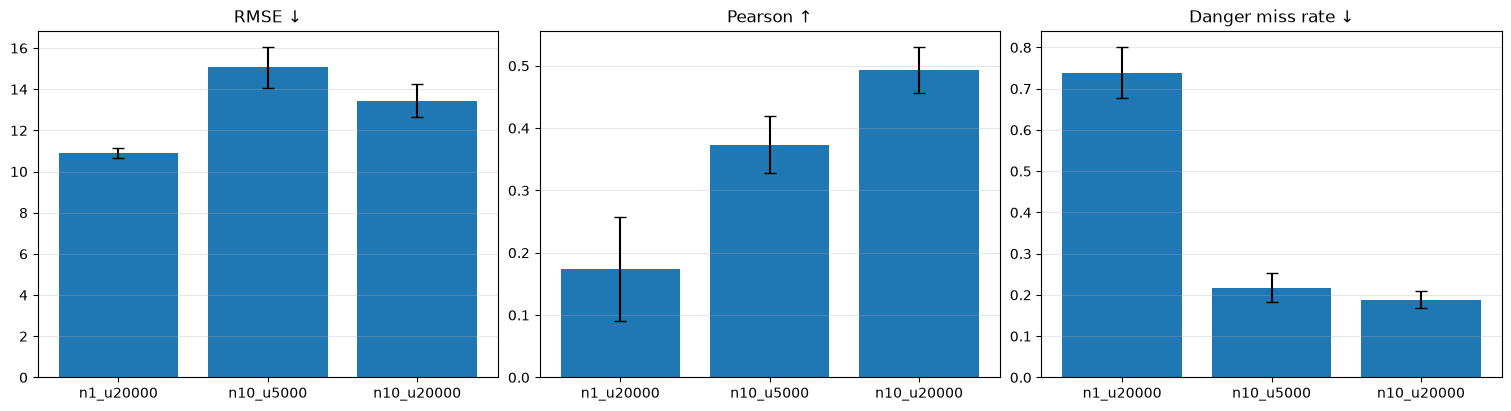

Saved: /Users/iniad/Documents/#lab/Safe-RL_20260915/Codes/runs/n_step_final_validation/large_validation_comparison.png


In [5]:
METRICS = ['mae','rmse','pearson','spearman','false_negative_rate','false_positive_rate','coverage','ucb_mean']
aggregate = {}
for label, n_step, milestone in CANDIDATES:
    rows = [r for r in validation_results if r['label'] == label]
    aggregate[label] = {'n_step': n_step, 'milestone': milestone, **{key: {'mean': float(np.mean([r[key] for r in rows])), 'values': [r[key] for r in rows]} for key in METRICS}}
report = {'validation': '20 geometry/N x 3 stochastic rollouts', 'd_cost': D_COST, 'aggregate': aggregate, 'by_seed': validation_results}
(OUTPUT_RUN / 'final_report.json').write_text(json.dumps(report, indent=2), encoding='utf-8')
display(report['aggregate'])
labels = [x[0] for x in CANDIDATES]
fig, axes = plt.subplots(1, 3, figsize=(15, 4), constrained_layout=True)
for ax, key, title in zip(axes, ['rmse','pearson','false_negative_rate'], ['RMSE ↓','Pearson ↑','Danger miss rate ↓']):
    means = [aggregate[label][key]['mean'] for label in labels]; errors = [np.std(aggregate[label][key]['values']) for label in labels]
    ax.bar(labels, means, yerr=errors, capsize=4); ax.set_title(title); ax.grid(axis='y', alpha=.3)
figure_path = OUTPUT_RUN / 'large_validation_comparison.png'
fig.savefig(figure_path, dpi=170); plt.show(); print('Saved:', figure_path)

## 2. Online CAL Pilot（n=10）

旧Mini Pilotと同じ30 scenario・seed・`d_cost=6`・dual LRを再利用します。新規学習として開始し、offline診断checkpointは初期値に使いません。`cost_target_n_step=10` だけを追加します。TensorBoardは自動起動し、Notebook内にはtqdmを表示します。

In [6]:
training_bank = load_scenario_bank(SOURCE_RUN / 'training_bank.json')
calibration_bank = load_scenario_bank(SOURCE_RUN / 'calibration_bank.json')
online_overrides = json.loads((SOURCE_RUN / 'resolved_config.json').read_text(encoding='utf-8'))
online_overrides['device'] = 'mps'
online_overrides['learning'].update({'d_cost': D_COST, 'cost_target_n_step': 10})
online_overrides['training'].update({'total_environment_steps_budget': None, 'checkpoint_every_episodes': 1})
online_overrides['monitoring'].update({'enabled': True, 'progress_bar': True, 'tensorboard': True, 'auto_launch_tensorboard': True, 'open_browser': True})
online_config = load_config(ROOT / 'configs' / 'full.yaml', overrides=online_overrides)
assert online_config.learning.cost_target_n_step == 10 and online_config.learning.d_cost == 6.0
ONLINE_RUN.mkdir(parents=True, exist_ok=True)
(ONLINE_RUN / 'resolved_config.json').write_text(json.dumps(online_config.to_dict(), indent=2), encoding='utf-8')
print({'episodes': len(training_bank), 'N_order': [x['actual_agent_count'] for x in training_bank[:12]], 'cost_target_n_step': online_config.learning.cost_target_n_step, 'd_cost': online_config.learning.d_cost, 'dual_lr': online_config.learning.cal_lambda_lr, 'learning_starts': online_config.training.learning_starts})

{'episodes': 30, 'N_order': [2, 4, 8, 2, 4, 8, 2, 4, 8, 2, 4, 8], 'cost_target_n_step': 10, 'd_cost': 6.0, 'dual_lr': 0.001, 'learning_starts': 2000}


In [7]:
if RUN_ONLINE_PILOT:
    latest = ONLINE_RUN / 'checkpoints' / 'latest.pt'
    final = ONLINE_RUN / 'checkpoints' / 'final.pt'
    online_trainer = SafeRLTrainer(online_config, build_env(online_config), ONLINE_RUN / 'training')
    if RESUME_ONLINE_IF_AVAILABLE and latest.exists():
        online_trainer.load_checkpoint(latest, resume_training=True)
        online_trainer.logger.truncate_after_episode(online_trainer.completed_episodes)
        print(f'{online_trainer.completed_episodes} episode地点から再開します。')
    remaining = len(training_bank) - online_trainer.completed_episodes
    display(HTML(f"<b>TensorBoard:</b> 学習開始後に自動起動します。ログ: <code>{ONLINE_RUN / 'training' / 'tensorboard'}</code>"))
    try:
        history = online_trainer.train(episodes=remaining, scenarios=training_bank, live_display=True, checkpoint_path=latest) if remaining > 0 else []
        online_trainer.save_checkpoint(final)
    finally:
        online_trainer.env.close()
    print({'completed_episodes': online_trainer.completed_episodes, 'environment_steps': online_trainer.total_environment_steps, 'gradient_updates': online_trainer.total_gradient_updates, 'checkpoint': str(final)})
else:
    print('RUN_ONLINE_PILOT=False: online学習をスキップしました。')

Training:   0%|          | 0/30 [00:00<?, ?episode/s]

TensorBoard: http://127.0.0.1:61598/
{'completed_episodes': 30, 'environment_steps': 11863, 'gradient_updates': 9864, 'checkpoint': '/Users/iniad/Documents/#lab/Safe-RL_20260915/Codes/runs/online_cal_n10_dcost6_mps/checkpoints/final.pt'}


## 3. Online Pilotの正式Calibrationと旧Pilot比較

In [8]:
from uav_safe_marl.evaluation import calibrate_cost_critic, evaluate_mean_policy_cost_diagnostic

final = ONLINE_RUN / 'checkpoints' / 'final.pt'
if not final.exists(): raise FileNotFoundError('Online Pilotの学習セルを先に完了してください。')
eval_overrides = deepcopy(online_config.to_dict())
eval_overrides['monitoring'].update({'enabled': False, 'progress_bar': False, 'tensorboard': False, 'auto_launch_tensorboard': False, 'open_browser': False})
eval_config = load_config(ROOT / 'configs' / 'full.yaml', overrides=eval_overrides)
evaluator = SafeRLTrainer(eval_config, build_env(eval_config), ONLINE_RUN / 'frozen_evaluation')
evaluator.load_checkpoint(final, resume_training=False)
try:
    calibration = calibrate_cost_critic(evaluator, calibration_bank, repeats=3, output_dir=ONLINE_RUN / 'cost_calibration')
    mean_diagnostic = evaluate_mean_policy_cost_diagnostic(evaluator, calibration_bank, repeats=1, output_dir=ONLINE_RUN / 'mean_policy_diagnostic')
finally:
    evaluator.env.close()
print(json.dumps({'formal_stochastic_calibration': calibration['overall'], 'mean_policy_diagnostic': {k:v for k,v in mean_diagnostic.items() if k != 'rows'}}, ensure_ascii=False, indent=2))

{
  "formal_stochastic_calibration": {
    "count": 27,
    "mc_return_mean": 42.149618448789276,
    "mc_return_median": 36.51929820624244,
    "mean_estimate_bias": -18.71747036308914,
    "ucb_estimate_bias": -13.286042195534074,
    "mean_estimate_mae": 36.33808083574421,
    "mean_estimate_rmse": 43.30551916893586,
    "ucb_estimate_mae": 35.28104577811119,
    "correlation": 0.06783221238014653,
    "empirical_ucb_coverage": 0.4444444444444444,
    "mc_return_p75": 70.94429340261718,
    "mc_return_p90": 97.81373722547139,
    "mc_return_p95": 101.21393061455105,
    "mc_return_max": 102.20398559915684
  },
  "mean_policy_diagnostic": {
    "definition": "deterministic mean-action deployment diagnostic; not SAC Cost Critic calibration",
    "diagnostic_kind": "mean_policy_deployment_cost",
    "runtime_hocbf": true,
    "execution_mode": "mean",
    "critic_rollout_semantics_match": false,
    "count": 9,
    "discounted_episode_cost_mean": 40.99084442471356,
    "discounted_epis

{'episodes': 30,
 'environment_steps': 11863,
 'gradient_updates': 9864,
 'cost_target_n_step': 10,
 'd_cost': 6.0,
 'final_lambda': 228.4760026683809,
 'max_lambda': 228.4760026683809,
 'mean_discounted_training_cost': 24.736280542693176,
 'calibration_mc_mean': 42.149618448789276,
 'calibration_ucb_mean': 28.863576253255207,
 'calibration_mae': 35.28104577811119,
 'calibration_coverage': 0.4444444444444444,
 'fraction_mc_above_d_cost': 0.7407407407407407,
 'fraction_ucb_above_d_cost': 1.0}

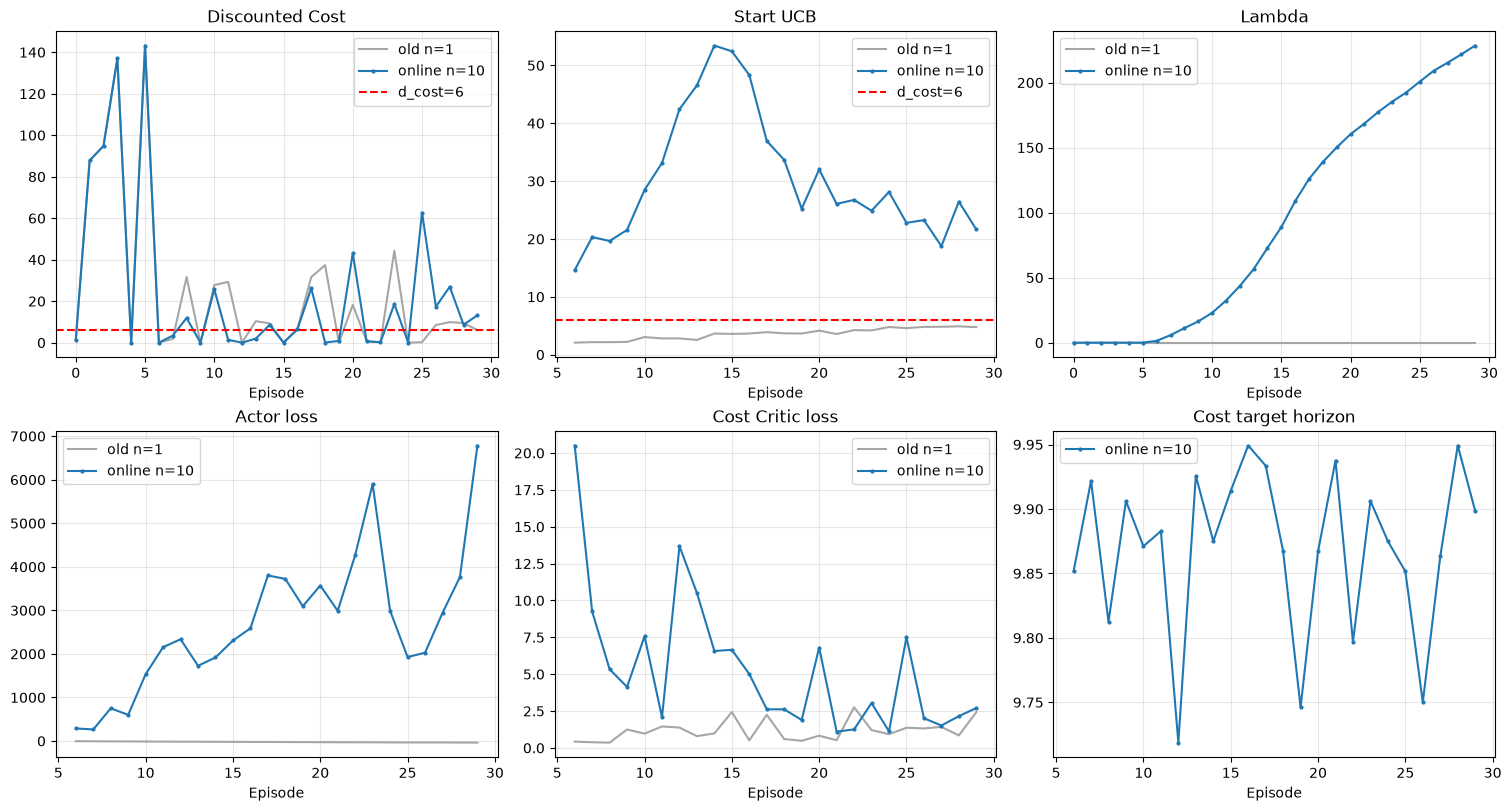

Saved: /Users/iniad/Documents/#lab/Safe-RL_20260915/Codes/runs/online_cal_n10_dcost6_mps/online_pilot_comparison.png


In [9]:
new_metrics = [json.loads(line) for line in (ONLINE_RUN/'training'/'metrics.jsonl').read_text(encoding='utf-8').splitlines() if line.strip()]
old_metrics_path = SOURCE_RUN / 'training' / 'metrics.jsonl'
old_metrics = [json.loads(line) for line in old_metrics_path.read_text(encoding='utf-8').splitlines() if line.strip()] if old_metrics_path.exists() else []
mc = np.asarray([r['discounted_episode_cost'] for r in calibration['rows']], float)
ucb = np.asarray([r['start_state_cost_ucb'] for r in calibration['rows']], float)
summary = {'episodes': len(new_metrics), 'environment_steps': new_metrics[-1]['cumulative_environment_steps'], 'gradient_updates': new_metrics[-1]['gradient_updates'], 'cost_target_n_step': 10, 'd_cost': D_COST, 'final_lambda': new_metrics[-1]['lambda'], 'max_lambda': float(max(r['lambda'] for r in new_metrics)), 'mean_discounted_training_cost': float(np.mean([r['discounted_episode_cost'] for r in new_metrics])), 'calibration_mc_mean': float(mc.mean()), 'calibration_ucb_mean': float(ucb.mean()), 'calibration_mae': calibration['overall']['ucb_estimate_mae'], 'calibration_coverage': calibration['overall']['empirical_ucb_coverage'], 'fraction_mc_above_d_cost': float(np.mean(mc>D_COST)), 'fraction_ucb_above_d_cost': float(np.mean(ucb>D_COST))}
(ONLINE_RUN/'online_pilot_summary.json').write_text(json.dumps(summary, indent=2), encoding='utf-8')
display(summary)
fig, axes = plt.subplots(2, 3, figsize=(15, 8), constrained_layout=True)
series = [('discounted_episode_cost','Discounted Cost'),('dual_constraint_estimate','Start UCB'),('lambda','Lambda'),('actor_loss','Actor loss'),('cost_critic_loss','Cost Critic loss'),('cost_target_mean_horizon','Cost target horizon')]
for ax,(key,title) in zip(axes.flat,series):
    if old_metrics and key in old_metrics[-1]: ax.plot([r.get(key,np.nan) for r in old_metrics], color='0.65', label='old n=1')
    ax.plot([r.get(key,np.nan) for r in new_metrics], marker='o', markersize=2, label='online n=10')
    if key in {'discounted_episode_cost','dual_constraint_estimate'}: ax.axhline(D_COST,color='red',linestyle='--',label='d_cost=6')
    ax.set_title(title); ax.set_xlabel('Episode'); ax.grid(alpha=.3); ax.legend()
figure_path = ONLINE_RUN/'online_pilot_comparison.png'
fig.savefig(figure_path,dpi=170); plt.show(); print('Saved:',figure_path)